In [1]:
import pandas as pd
import numpy as np
from tensordict import TensorDict
import math
import torch
import torchrl.data.tensor_specs
from torch.distributions.uniform import Uniform

torchrl.data.tensor_specs.CompositeSpec = torchrl.data.tensor_specs.Composite
torchrl.data.tensor_specs.BoundedTensorSpec = torchrl.data.tensor_specs.Bounded
torchrl.data.tensor_specs.UnboundedDiscreteTensorSpec = (
    torchrl.data.tensor_specs.UnboundedDiscrete
)
torchrl.data.tensor_specs.UnboundedContinuousTensorSpec = (
    torchrl.data.tensor_specs.UnboundedContinuous
)
from routefinder.models.model import RouteFinderBase, RouteFinderMoE
from routefinder.models.baselines.mvmoe.model import MVMoE
from routefinder.models.baselines.mtpomo.model import MTPOMO
from routefinder.envs.mtvrp import MTVRPEnv, MTVRPGenerator
import json
import time
import pickle
from io import BytesIO
from itertools import cycle
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib as mpl
from rl4co.utils.ops import unbatchify, gather_by_index
import data_process
from packing import items_packing
import opt_utils
from opt_cf import env_config as opt_config

/Users/n.tu/3T/test/routefinder/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
input_path = "c468df24-0163-4125-907e-68d32291418d"
query = f"""
    SELECT *
    FROM c
    WHERE c.req_id = "{input_path}"
"""
data = opt_utils.query_cosmos('orders', 'hgs-input', query)
data = data[0]

In [3]:
# data_path = "3t_data/7d13bb22-5bf2-4268-96e4-cb56b4fc00ff.json"
# with open(data_path, "r") as file:
#         data = json.load(file)

In [4]:
variant = data["variant"]
biggest_equipment = data["biggest_equipment"]
unit_type = data["unit_type"]
num_stack = data["num_stack"]
multi_visit_penalty = data["multi_visit_penalty"]
req_id = data["req_id"]
col_date = data["col_date"]
directory_ref = data["directory_reference"]

In [5]:
equipment = pd.DataFrame(data["equipment_list"])
equipment["floor_area"] = (
    equipment["internalLengthMillimeter"]
    / 1000
    * equipment["internalWidthMillimeter"]
    / 1000
    * 0.95
)  # 5% reserved for loading
if unit_type == "Volume":
    equipment["palletSpacesUK"] = equipment[
        "floor_area"
    ]  # for boxes, optimize based on floor area instead of pallets
    equipment["volume"] = equipment["volume"] * 0.9  # 10% reserved for loading
equipment

,id,name,code,internalLengthMillimeter,internalWidthMillimeter,internalHeightMillimeter,maximumPayloadKg,palletSpacesUK,palletSpacesEU,volume,maximumDrivingTimeInMinutes,floor_area
0,2,Curtain 13.6,Curtain 13.6,13420,2490,2600,32000,26,33,90,540,31.74501


In [6]:
def process_backhaul_order(df):
    source_name = statistics.mode(df["source_name"].tolist() + df["dest_name"].tolist())
    df_delivery = df[df.source_name == source_name]
    df_delivery = df_delivery.assign(backhaul=1)
    #
    df_pickup = df[~(df.source_name == source_name)]
    for row in df_pickup.itertuples():
        source_id = row.dest_id
        source_name = row.dest_name
        source_lat = row.dest_lat
        source_long = row.dest_long
        dest_id = row.source_id
        dest_name = row.source_name + " pickup"
        dest_lat = row.source_lat
        dest_long = row.source_long
        #
        df_pickup.loc[row.Index, "source_id"] = source_id
        df_pickup.loc[row.Index, "source_name"] = source_name
        df_pickup.loc[row.Index, "source_lat"] = source_lat
        df_pickup.loc[row.Index, "source_long"] = source_long
        df_pickup.loc[row.Index, "dest_id"] = dest_id
        df_pickup.loc[row.Index, "dest_name"] = dest_name
        df_pickup.loc[row.Index, "dest_lat"] = dest_lat
        df_pickup.loc[row.Index, "dest_long"] = dest_long
    df_pickup = df_pickup.assign(backhaul=-1)
    df = pd.concat([df_delivery, df_pickup], ignore_index=True)
    return df

In [7]:
df = pd.DataFrame(data['order'])
if variant == "vrpbtw":
    df = process_backhaul_order(df)
else:
    df = df.assign(backhaul=1)

In [8]:
df = data_process.process_order(df)

========== GET ORDERS = DONE ==========


In [9]:
(
    locations,
    order_number_id,
    full_load_route,
    dest_names,
    coordinates,
    weights,
    volumes,
    pallets,
    distances,
    time_windows,
    durations,
    address_guids,
    speed
) = data_process.process_account(
    df,
    num_stack=num_stack,
    equipment=equipment,
    biggest_equipment=biggest_equipment,
    unit_type=unit_type,
    variant=variant,
    req_id=req_id,
    directory_ref=directory_ref,
)

Get all routes from cached data
========== PROCESS ACCOUNT ORDERS = DONE ==========


In [10]:
locations

,source_name,dest_name,source_lat,source_long,dest_lat,dest_long,weight,volume,delivery_time_start,delivery_time_end,...,width,unit_id,order_number_id,proxy_volume,proxy_pse,delivery_start_minutes_of_day,delivery_end_minutes_of_day,over_weight,over_volume,over_pallet
0,H.J. Heinz Company Ltd NDC,Arthur David HDC_34a1340f-bfd8-415b-9d7e-b6bec...,53.554497,-2.67764,51.309692,-2.531188,3015,9.36,00:00:00,06:00:00,...,[1000],[a15d06f7-8fcf-499a-9200-ab9844ea8855],"[[Wesleymimp1], [a15d06f7-8fcf-499a-9200-ab984...",9.36,3.0,0,360,0.099178,0.109474,0.115385
1,H.J. Heinz Company Ltd NDC,Asda Chepstow (7441) RA_f7e9a680-3299-47b5-ac7...,53.554497,-2.67764,51.616070,-2.676922,8000,24.96,00:00:00,06:00:00,...,[1000],[9720716e-30b2-4b33-9e84-8307a1086051],"[[Wesleymimp2], [9720716e-30b2-4b33-9e84-8307a...",24.96,8.0,0,360,0.263158,0.291930,0.307692
2,H.J. Heinz Company Ltd NDC,Asda Dartford (7442) RA_aa4fedd1-cb3c-4f57-8d5...,53.554497,-2.67764,51.452730,0.265309,8000,24.96,00:00:00,06:00:00,...,[1000],[84c8fd98-ee82-497d-9595-8816f11ac688],"[[Wesleymimp3], [84c8fd98-ee82-497d-9595-8816f...",24.96,8.0,0,360,0.263158,0.291930,0.307692
3,H.J. Heinz Company Ltd NDC,Asda Lutterworth (7446) RA_e42466cd-aac6-432a-...,53.554497,-2.67764,52.463997,-1.246159,8000,24.96,00:00:00,06:00:00,...,[1000],[c8bc39c4-4c21-4fa1-8e7b-2de047f961f9],"[[Wesleymimp4], [c8bc39c4-4c21-4fa1-8e7b-2de04...",24.96,8.0,0,360,0.263158,0.291930,0.307692
4,H.J. Heinz Company Ltd NDC,Astha Group UK Ltd_5091dc4b-bd9a-42d4-ac3a-58a...,53.554497,-2.67764,51.563927,-0.299779,3040,9.36,00:00:00,06:00:00,...,[1000],[29fe349f-9609-4955-bc1f-971bd16ccc97],"[[Wesleymimp5], [29fe349f-9609-4955-bc1f-971bd...",9.36,3.0,0,360,0.100000,0.109474,0.115385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,H.J. Heinz Company Ltd NDC,Tesco Thurrock (400) RA_767a2fe7-f0ff-4d14-b1d...,53.554497,-2.67764,51.480762,0.261464,8000,24.96,00:00:00,06:00:00,...,[1000],[408abd78-7b94-421e-af16-2bbee729a28f],"[[Wesleymimp80], [408abd78-7b94-421e-af16-2bbe...",24.96,8.0,0,360,0.263158,0.291930,0.307692
74,H.J. Heinz Company Ltd NDC,The Cornwall Bakery_930222e0-9387-4d81-95c0-52...,53.554497,-2.67764,50.504460,-4.303708,6186,18.72,00:00:00,06:00:00,...,[1000],[bf3dcae0-2047-4cf1-b067-7afe441bf8c1],"[[Wesleymimp81], [bf3dcae0-2047-4cf1-b067-7afe...",18.72,6.0,0,360,0.203487,0.218947,0.230769
75,H.J. Heinz Company Ltd NDC,Waitrose Milton Keynes RA_fd81ea84-ff1e-4c96-8...,53.554497,-2.67764,52.040142,-0.669972,8000,24.96,00:00:00,06:00:00,...,[1000],[5d503e06-15eb-4afd-9c67-21b4ae965ffc],"[[Wesleymimp85], [5d503e06-15eb-4afd-9c67-21b4...",24.96,8.0,0,360,0.263158,0.291930,0.307692
76,H.J. Heinz Company Ltd NDC,Wm Morrisons Belshill (NEW)_4c93c504-0d91-4e34...,53.554497,-2.67764,55.828130,-4.041567,8000,24.96,00:00:00,06:00:00,...,[1000],[d891ea0b-7974-4553-ab8d-328e5f4cb75d],"[[Wesleymimp86], [d891ea0b-7974-4553-ab8d-328e...",24.96,8.0,0,360,0.263158,0.291930,0.307692


In [11]:
if unit_type == 'Pallet':
    capacity = equipment[equipment.name == biggest_equipment]['palletSpacesUK'].values[0]
elif unit_type == "Volume":
    capacity = equipment[equipment.name == biggest_equipment]['volume'].values[0]
capacity

np.int64(26)

In [12]:
scale_factor = 0.2  # 3, 0.2
min_coord = np.array(coordinates).min(axis=0)
max_coord = np.array(coordinates).max(axis=0)
coord_range = max_coord - min_coord
distance_scaler = coord_range.max()
coordinates_scaled = (np.array(coordinates) - min_coord) / distance_scaler
coordinates_scaled = np.expand_dims(coordinates_scaled, axis=0)
# coordinates = np.expand_dims(coordinates, axis=0)
#
max_time_window = 1440
time_scaler = max_time_window / scale_factor  # 1440/3
service_time = np.array([opt_config.client_service_duration] * (len(weights) - 1))
service_time = torch.Tensor(service_time.reshape((1, -1))) / time_scaler
tw_start = (
    torch.Tensor(
        np.array(locations["delivery_start_minutes_of_day"].tolist()).reshape((1, -1))
    )
    / time_scaler
)  # [1, n]
tw_end = (
    torch.Tensor(
        np.array(locations["delivery_end_minutes_of_day"].tolist()).reshape((1, -1))
    )
    / time_scaler
)  # [1, n]
depot_tw, depot_service_time = torch.tensor([[0.0, scale_factor]]), torch.zeros(
    (1, 1), device=service_time.device
)
tw = torch.stack([tw_start.squeeze(0), tw_end.squeeze(0)], dim=1)
tw = torch.cat([depot_tw, tw], dim=0)
service_time = torch.cat([depot_service_time, service_time], dim=1)
if unit_type == "Volume":
    node_demand = np.array(volumes[1:])
    node_demand = torch.Tensor(node_demand.reshape((1, -1))) / capacity
elif unit_type == "Pallet":
    node_demand = np.array(pallets[1:])
    node_demand = torch.Tensor(node_demand.reshape((1, -1))) / (capacity + 0.1) # [1, n]

In [13]:
speed = speed / 60 * time_scaler
distances_limit = 900
distance_matrix_scaler = 3
distances_scaled = np.array(distances) * distance_matrix_scaler / distances_limit
durations_scaled = np.array(durations) / time_scaler

In [14]:
is_open = True if 'o' in variant else False

In [15]:
td_instance = TensorDict(
    {
        "locs": torch.from_numpy(coordinates_scaled[0]).float(),
        "demand_linehaul": node_demand[0],
        "capacity_original": torch.tensor([capacity]),
        "service_time": service_time[0],
        "speed": torch.tensor([speed]).float(),
        "time_windows": tw,
        "distance_limit": torch.tensor([distance_matrix_scaler]).float(),
        "distance_matrix": torch.from_numpy(distances_scaled).float(),
        "duration_matrix": torch.from_numpy(durations_scaled).float(),
        "open_route": torch.tensor([is_open], dtype=torch.bool),
    },
    batch_size=[],
)[None]

In [16]:
def evaluate(
    model,
    td,
    env,
    num_augment=8,
    num_starts=None,
):

    with torch.inference_mode():
        with torch.amp.autocast("cpu"):
            n_start = env.get_num_starts(td) if num_starts is None else num_starts

            if num_augment > 1:
                td = model.augment(td)

            # Evaluate policy
            out = model.policy(
                td, env, phase="test", num_starts=n_start, return_actions=True
            )

            # Unbatchify reward to [batch_size, num_augment, num_starts].
            reward = unbatchify(out["reward"], (num_augment, n_start))

            if n_start > 1:
                # max multi-start reward
                max_reward, max_idxs = reward.max(dim=-1)
                out.update({"max_reward": max_reward})

                if out.get("actions", None) is not None:
                    # Reshape batch to [batch_size, num_augment, num_starts, ...]
                    actions = unbatchify(out["actions"], (num_augment, n_start))
                    out.update(
                        {
                            "best_multistart_actions": gather_by_index(
                                actions, max_idxs, dim=max_idxs.dim()
                            )
                        }
                    )
                    out["actions"] = actions

            # Get augmentation score only during inference
            if num_augment > 1:
                # If multistart is enabled, we use the best multistart rewards
                reward_ = max_reward if n_start > 1 else reward
                max_aug_reward, max_idxs = reward_.max(dim=1)
                out.update({"max_aug_reward": max_aug_reward})

                if out.get("actions", None) is not None:
                    actions_ = (
                        out["best_multistart_actions"] if n_start > 1 else out["actions"]
                    )
                    out.update({"best_aug_actions": gather_by_index(actions_, max_idxs)})

            return out

In [17]:
if variant == "ovrptw":
    variant_preset = "ovrpltw"
elif variant == "vrptw":
    variant_preset = "vrpltw"

In [18]:
device = "cpu"
PATH = "checkpoints/100/rf-transformer.ckpt"
model = RouteFinderBase.load_from_checkpoint(PATH, map_location=device, weights_only=False)
model.eval().to(device)
#
policy = model.policy
policy = policy.to(device).eval()
# Create env
generator = MTVRPGenerator(num_loc=100, variant_preset=variant_preset)
env = MTVRPEnv(generator, check_solution=True).to(device) # Add .to(device) here
#
td_instance = td_instance.to(device)
td_reset = env.reset(td_instance).to(device)

start = time.time()
actions = evaluate(model, td_reset.clone(), env)["best_aug_actions"]

/Users/n.tu/3T/test/routefinder/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/n.tu/3T/test/routefinder/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Solution checking is enabled. This may slow down the environment. We recommend disabling this for training by passing `check_solution=False`.


In [19]:
def extract_routes_from_actions(actions, drop_empty_routes=True, is_open=False):
    """
    Parse giant-tour actions into per-route lists. 
    
    Args:
        actions: 1D or 2D Tensor/list. If 2D, shape [batch, seq_len].
        drop_empty_routes: if True, omit routes that contain no customers (i.e., [0] or [0, 0]).
        is_open: if True, routes end at the last customer (e.g., [0, 1, 2]). 
                 if False, routes return to the depot (e.g., [0, 1, 2, 0]).
    Returns:
        If input was 1D: list[list[int]] of routes.
        If input was 2D: list of batches -> list[list[list[int]]].
    """
    single = False
    if isinstance(actions, torch.Tensor):
        actions = actions.cpu()
        if actions.dim() == 1:
            actions = actions.unsqueeze(0)
            single = True
    elif isinstance(actions, (list, tuple)):
        if len(actions) > 0 and not isinstance(actions[0], (list, tuple)):
            actions = [list(actions)]
            single = True
    else:
        raise TypeError("actions must be a tensor or an iterable")
    routes_batch = []
    for seq in actions:
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
        seq = [int(x) for x in seq]
        # Split on zeros
        segments = []
        curr = []
        for val in seq:
            if val == 0:
                segments.append(curr)
                curr = []
            else:
                curr.append(val)
        if curr:
            segments.append(curr)
        # Convert segments to routes
        routes = []
        for seg in segments:
            # Skip empty routes if requested
            if len(seg) == 0 and drop_empty_routes:
                continue
            # Start at depot
            route = [0] + seg
            # If it's a closed route, return to depot
            if not is_open:
                route.append(0)
            routes.append(route)
        routes_batch.append(routes)
    return routes_batch[0] if single else routes_batch

In [20]:
routes = extract_routes_from_actions(actions, is_open=is_open)
print(routes[0])
print(len(routes[0]))

[[0, 58, 75], [0, 8, 13, 21], [0, 37], [0, 6, 27, 52, 62], [0, 17, 68], [0, 54, 2], [0, 28, 30, 1, 57, 43], [0, 18, 41, 40], [0, 65, 19, 56], [0, 60, 11], [0, 73, 55, 69, 5], [0, 3, 44, 53], [0, 23, 78, 22], [0, 7, 74, 33], [0, 4, 20, 32, 45], [0, 25, 50, 34, 71], [0, 61, 59, 72], [0, 76, 14, 10], [0, 35, 51, 26], [0, 63, 31, 12], [0, 47, 39, 36], [0, 66, 24, 15], [0, 70, 16, 38, 64], [0, 67, 42, 46], [0, 48, 29, 77], [0, 9, 49]]
26


In [21]:
def compute_schedule(
    route,                  # list of location indices (including depot)
    travel_time_matrix,     # 2D list or numpy array
    service_durations,      # list indexed by location
    time_windows,           # list of (start, end)
    start_time=0
):
    schedule = []
    location_arrival_time = []
    current_time = start_time
    for i in range(len(route)):
        loc = route[i]
        if i == 0:
            # Depot start
            arrival = current_time
        else:
            prev = route[i - 1]
            travel_time = travel_time_matrix[prev][loc]
            arrival = current_time + travel_time
        tw_start, tw_end = time_windows[loc]
        # Waiting if early
        wait = max(0, tw_start - arrival)
        # Start service
        start_service = arrival + wait
        # Departure time
        service_duration = service_durations if loc != 0 else 0
        departure = start_service + service_duration
        # Time warp (late arrival)
        time_warp = max(0, arrival - tw_end)
        schedule.append({
            "location": loc,
            "arrival": arrival,
            "wait": wait,
            "start_service": start_service,
            "departure": departure,
            "time_warp": time_warp,
        })
        location_arrival_time.append(arrival)
        # Move time forward
        current_time = departure
    return schedule, location_arrival_time

In [22]:
schedule, location_arrival_time = compute_schedule(
    routes[0][0],
    durations,
    opt_config.client_service_duration,
    time_windows,
    start_time=0
)
for s in schedule:
    print(s)

{'location': 0, 'arrival': 0, 'wait': 0, 'start_service': 0, 'departure': 0, 'time_warp': 0}
{'location': 58, 'arrival': 239, 'wait': 0, 'start_service': 239, 'departure': 249, 'time_warp': 0}
{'location': 75, 'arrival': 319, 'wait': 0, 'start_service': 319, 'departure': 329, 'time_warp': 0}


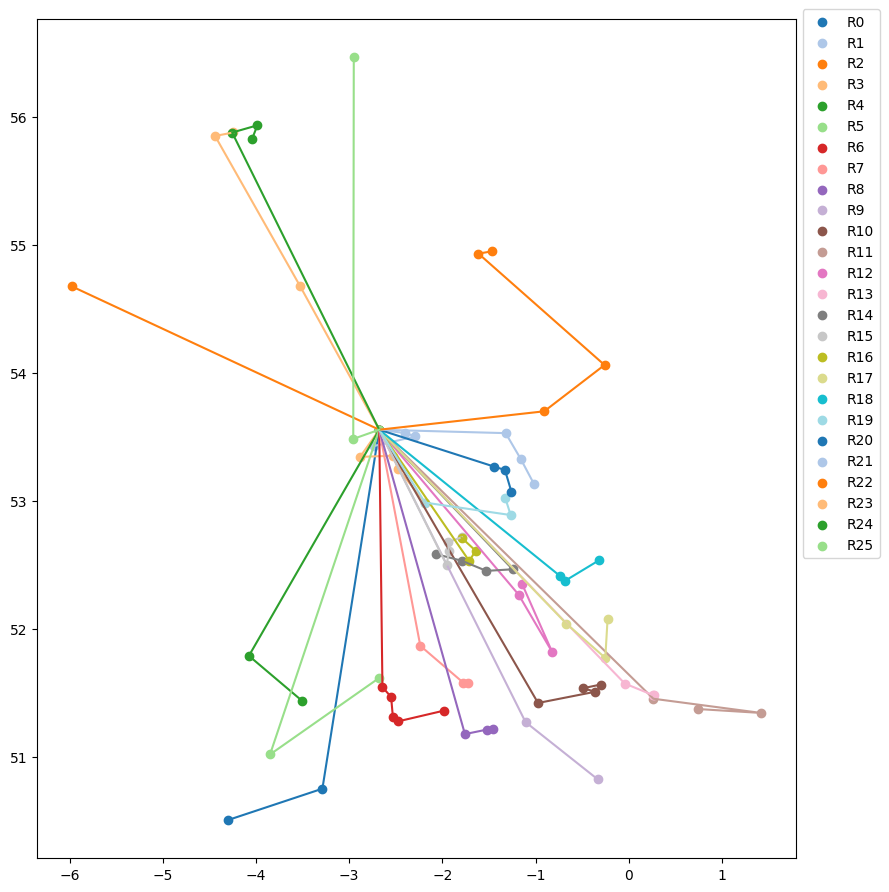

In [23]:
def route_visualize(coordinates, routes):
    coordinates = pd.DataFrame(coordinates, columns=["x", "y"])
    num_location = coordinates.shape[0]
    #
    cmap = mpl.colormaps["tab20"]
    colors = cycle(cmap.colors)
    # Now the figure
    figsize = [max(int(num_location / 8), 5), max(int(num_location / 8), 5)]
    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    for r, tour in enumerate(routes):
        c = next(colors)
        t = np.array(tour)
        x = coordinates.values[t, 0]
        y = coordinates.values[t, 1]
        ax.scatter(x, y, color=c, label=f"R{r}")
        ax.plot(x, y, color=c)

    ax.legend(loc="upper left", bbox_to_anchor=(1, 1.02))
    fig.tight_layout()
    plt.show()
    return
route_visualize(coordinates, routes[0])

In [24]:
route_pallet_delivery = []
route_weight_delivery = []
route_volume_delivery = []
route_duration = []
route_distance = []
loc_service_time = 10
for route in routes[0]:
    pallet_delivery, weight_delivery, volume_delivery= 0, 0, 0
    duration = 0
    distance = 0
    for i in range(len(route) -1):
        distance += distances[route[i]][route[i+1]]
        duration += durations[route[i]][route[i+1]] + loc_service_time
        pallet_delivery += pallets[route[i+1]]
        weight_delivery += weights[route[i+1]] 
        volume_delivery += volumes[route[i+1]]
    route_pallet_delivery.append(pallet_delivery)
    route_weight_delivery.append(weight_delivery)
    route_volume_delivery.append(volume_delivery)
    route_duration.append(duration)
    route_distance.append(distance)
print("Total distance", sum(route_distance))
print("Pallet", route_pallet_delivery)
print("Weight", route_weight_delivery)
print("Volume", route_volume_delivery)
print("Duration", route_duration)
print("Distance", route_distance)

Total distance 8868
Pallet [14.0, 24.0, 8.0, 26.0, 10.0, 16.0, 22.0, 24.0, 24.0, 18.0, 20.0, 24.0, 24.0, 24.0, 26.0, 22.0, 24.0, 24.0, 24.0, 24.0, 19.0, 24.0, 22.0, 20.0, 24.0, 16.0]
Weight [8186, 18000, 8000, 25043, 3673, 10000, 14985, 12000, 24000, 15992, 14040, 18000, 18000, 18000, 18902, 16002, 24000, 24000, 18000, 18000, 5782, 12000, 19994, 6314, 18000, 4000]
Volume [43.68, 74.88, 24.96, 81.11999999999999, 31.200000000000003, 49.92, 68.64, 74.88, 74.88, 56.160000000000004, 62.400000000000006, 74.88, 74.88, 74.88, 81.11999999999999, 68.64000000000001, 74.88, 74.88, 74.88, 74.88, 59.28, 74.88, 68.64000000000001, 62.400000000000006, 74.88, 49.92]
Duration [329, 119, 357, 176, 306, 361, 352, 225, 264, 330, 346, 367, 302, 313, 266, 207, 160, 276, 209, 168, 172, 203, 361, 338, 257, 307]
Distance [508, 89, 434, 148, 344, 560, 372, 278, 347, 483, 417, 533, 379, 392, 289, 191, 189, 352, 273, 178, 152, 225, 451, 432, 371, 481]


In [25]:
def get_route_delivery(df, equipment, routes, order_number_id, num_stack, unit_type, distances, durations, pallets, weights, volumes, time_windows):
    start_time = time.perf_counter()
    loc_service_time = opt_config.client_service_duration 
    route_delivery = []
    df_dict = df.set_index('id').to_dict(orient='index')
    #
    for index, route in enumerate(routes):
        _, location_arrival_time = compute_schedule(route, durations, opt_config.client_service_duration, time_windows, start_time=0)
        print(f"Loading check for route {index}.")
        order_id = []
        pallet_delivery = 0
        weight_delivery = 0
        volume_delivery = 0
        duration = 0
        distance = 0
        # Accumulate Order IDs
        for v in route:
            if v != 0:
                orderids = order_number_id[v - 1][1]
                order_id.extend(orderids)
        loading_items = {"num_stack": num_stack, "unit_type": unit_type, "items": []}
        for i in order_id:
            if i in df_dict:
                data = df_dict[i]
                loading_items["items"].append({
                    "id": i,
                    "height": data["height"],
                    "width": data["width"],
                    "length": data["length"],
                    "weight": data["weight"],
                    "quantity": data["quantity"],
                    "stack_on_top": data["stack_on_top"],
                    "stack_on_other": data["stack_on_other"],
                })

        # Calculate Route Metrics
        for i in range(len(route) - 1):
            distance += distances[route[i]][route[i+1]]
            duration += durations[route[i]][route[i+1]] + loc_service_time
            pallet_delivery += pallets[route[i+1]]
            weight_delivery += weights[route[i+1]] 
            volume_delivery += volumes[route[i+1]]

        # Determine order column
        if unit_type == 'Pallet':
            order_column = 'palletSpacesUK'
        elif unit_type == 'Weight':
            order_column = 'maximumPayloadKg'
        elif unit_type == 'Volume':
            order_column = 'volume'
        else:
            order_column = 'volume'
        sorted_equipment = equipment.sort_values(by=[order_column], ascending=False)
        ldm = float("inf")
        for i, row in enumerate(sorted_equipment.itertuples()):
            v_name = row.name
            v_weight = row.maximumPayloadKg
            v_pallet = row.palletSpacesUK
            v_volume = row.volume
            v_whd = [row.internalWidthMillimeter, row.internalHeightMillimeter, row.internalLengthMillimeter]
            if pallet_delivery <= v_pallet and weight_delivery <= v_weight and volume_delivery <= v_volume:
                best_ldm, init_ldm = items_packing(
                    loading_items["items"],
                    v_whd,
                    v_weight,
                    num_stack,
                    unit_type,
                    visualize=False,
                )
                if i == 0:
                    vehicle_weight_utilization = round(weight_delivery/v_weight, 3)
                    vehicle_volume_utilization = round(volume_delivery/v_volume, 3)
                    vehicle_pallet_utilization = round(pallet_delivery/v_pallet, 3)
                    ldm = round(best_ldm/1000, 2)
                    vehicle_name = v_name
                else:
                    if not math.isinf(best_ldm):
                        vehicle_weight_utilization = round(weight_delivery/v_weight, 3)
                        vehicle_volume_utilization = round(volume_delivery/v_volume, 3)
                        vehicle_pallet_utilization = round(pallet_delivery/v_pallet, 3)
                        ldm = round(best_ldm/1000, 2)
                        vehicle_name = v_name
            else:
                # print(f"Can not loading for route {index}, equipment {v_name}")
                break
        #
        route_delivery.append({
            "weight_delivery": weight_delivery,
            "volume_delivery": round(volume_delivery, 2),
            "pallet_delivery": pallet_delivery,
            "vehicle_weight_utilization": vehicle_weight_utilization,
            "vehicle_volume_utilization": vehicle_volume_utilization,
            "vehicle_pallet_utilization": vehicle_pallet_utilization,
            "ldm": ldm,
            "distance": distance,
            "location_arrival_time": location_arrival_time,
            "service_time": location_arrival_time[-1] - location_arrival_time[0],
            "vehicle_name": vehicle_name
        })
    loading_runtime = time.perf_counter() - start_time
    print(f"\nTotal Loading Check Time: {loading_runtime:.4f}s")
    return route_delivery

In [26]:
route_delivery = get_route_delivery(df, equipment, routes[0], order_number_id, num_stack, unit_type, distances, durations, pallets, weights, volumes, time_windows)
route_delivery

Loading check for route 0.
Loading check for route 1.
Loading check for route 2.
Loading check for route 3.
Loading check for route 4.
Loading check for route 5.
Loading check for route 6.
Loading check for route 7.
Loading check for route 8.
Loading check for route 9.
Loading check for route 10.
Loading check for route 11.
Loading check for route 12.
Loading check for route 13.
Loading check for route 14.
Loading check for route 15.
Loading check for route 16.
Loading check for route 17.
Loading check for route 18.
Loading check for route 19.
Loading check for route 20.
Loading check for route 21.
Loading check for route 22.
Loading check for route 23.
Loading check for route 24.
Loading check for route 25.

Total Loading Check Time: 2.6244s


[{'weight_delivery': 8186,
  'volume_delivery': 43.68,
  'pallet_delivery': 14.0,
  'vehicle_weight_utilization': 0.256,
  'vehicle_volume_utilization': 0.485,
  'vehicle_pallet_utilization': 0.538,
  'ldm': 7.0,
  'distance': 508,
  'location_arrival_time': [0, 239, 319],
  'service_time': 319,
  'vehicle_name': 'Curtain 13.6'},
 {'weight_delivery': 18000,
  'volume_delivery': 74.88,
  'pallet_delivery': 24.0,
  'vehicle_weight_utilization': 0.562,
  'vehicle_volume_utilization': 0.832,
  'vehicle_pallet_utilization': 0.923,
  'ldm': 12.0,
  'distance': 89,
  'location_arrival_time': [0, 37, 65, 109],
  'service_time': 109,
  'vehicle_name': 'Curtain 13.6'},
 {'weight_delivery': 8000,
  'volume_delivery': 24.96,
  'pallet_delivery': 8.0,
  'vehicle_weight_utilization': 0.25,
  'vehicle_volume_utilization': 0.277,
  'vehicle_pallet_utilization': 0.308,
  'ldm': 4.0,
  'distance': 434,
  'location_arrival_time': [0, 347],
  'service_time': 347,
  'vehicle_name': 'Curtain 13.6'},
 {'weig

In [27]:
def get_route_output(
    req_id,
    directory_ref,
    col_date,
    routes,
    locations,
    route_delivery,
    variant,
    dest_names,
    order_number_id,
    address_guids,
    distances,
    durations,
    full_load_route,
    runtime,
):
    all_routes = []
    for i, route in enumerate(routes):
        visits = []
        visit_index = []
        orderids = []
        all_order_number = []
        all_order_id = []
        matrix_component = []
        last_visit_name = ""
        #
        for cust in route[1:]:
            if cust != 0:
                visit = {}
                visit_name = dest_names[cust].split("_")[0]
                directoryReference = dest_names[cust].split("_")[1]
                order_number = order_number_id[cust - 1][0]
                orderids = order_number_id[cust - 1][1]
                visit_index.append(cust)
                all_order_number.extend(order_number)
                all_order_id.extend(orderids)
                if visit_name == last_visit_name:
                    visits[-1]["order_number"].append(order_number)
                    visits[-1]["orderIds"].extend(orderids)
                else:
                    visit["visit_name"] = visit_name
                    visit["directoryReference"] = directoryReference
                    visit["orderIds"] = orderids
                    visit["order_number"] = [order_number]
                    visits.append(visit)
                last_visit_name = visit_name
        source_info = {
            "visit_name": dest_names[0].split("_")[0],
            "directoryReference": dest_names[0].split("_")[1],
            "orderIds": all_order_id,
            "order_number": all_order_number,
        }
        visits.insert(0, source_info)
        visit_index.insert(0, 0)
        if "o" not in variant:
            visits.append(source_info)
            visit_index.append(0)
        #
        for j in range(len(visit_index) - 1):
            component = {
                "sourceId": address_guids[visit_index[j]],
                "destinationId": address_guids[visit_index[j + 1]],
                "drivingDistanceInMeters": int(
                    distances[visit_index[j]][visit_index[j + 1]] * 1000
                ),
                "travelTimeInSeconds": int(
                    durations[visit_index[j]][visit_index[j + 1]] * 60
                ),
            }
            matrix_component.append(component)
        #
        r_visit = {
            "route_id": i,
            "visits": visits,
            "distanceMatrix": matrix_component,
            "note": "routefinder",
        }
        r_delivery = route_delivery[i]
        route_detail = r_visit | r_delivery
        all_routes.append(route_detail)
    if len(full_load_route) > 0:
        all_routes.extend(full_load_route)

    # save actions
    buffer = BytesIO()
    locations.to_parquet(buffer, index=False)
    opt_utils.upload_file_to_blob(
        opt_config.connection_string,
        opt_config.output_container_name,
        f"locations/{req_id}.parquet",
        buffer.getvalue(),
    )

    opt_utils.upload_file_to_blob(
        opt_config.connection_string,
        opt_config.output_container_name,
        f"routes/{req_id}.pkl",
        pickle.dumps(routes),
    )
    output = {}
    output["status"] = True
    output["id"] = req_id
    output["directory_reference"] = directory_ref
    output["col_date"] = col_date
    output["routes"] = all_routes
    output["run_time"] = runtime
    return output

In [28]:
output = get_route_output(req_id, directory_ref, col_date, routes[0], locations, route_delivery, variant, dest_names, order_number_id,
                          address_guids, distances, durations, full_load_route, runtime=0)
output

{'status': True,
 'id': 'c468df24-0163-4125-907e-68d32291418d',
 'directory_reference': '5cc875c2-1cfd-49c4-a304-21defe040753',
 'col_date': '2026-06-10T00:00:00',
 'routes': [{'route_id': 0,
   'visits': [{'visit_name': 'H.J. Heinz Company Ltd NDC',
     'directoryReference': '6c8b58cc-e594-49ca-a54c-3b119ff1f332',
     'orderIds': ['73205eb5-8f2f-46e8-ab80-d552e05773f7',
      'bf3dcae0-2047-4cf1-b067-7afe441bf8c1'],
     'order_number': ['Wesleymimp71', 'Wesleymimp81']},
    {'visit_name': 'SMART BUILD SUPPLIES LTD',
     'directoryReference': '6f6dee46-6394-46c2-898f-ee0167acd92c',
     'orderIds': ['73205eb5-8f2f-46e8-ab80-d552e05773f7'],
     'order_number': [['Wesleymimp71']]},
    {'visit_name': 'The Cornwall Bakery',
     'directoryReference': '930222e0-9387-4d81-95c0-52af5b12a315',
     'orderIds': ['bf3dcae0-2047-4cf1-b067-7afe441bf8c1'],
     'order_number': [['Wesleymimp81']]}],
   'distanceMatrix': [{'sourceId': 'e44e374c-2c30-4966-bb36-9970dbb23660',
     'destinationId'